# ResNet-18 und Evaluation für Pseudo-Labelling im 3D-Druck

Dieses Notebook baut auf `main.ipynb` auf: Dort werden die 9 Bauteile pro Schicht gecroppt, ein Autoencoder trainiert und daraus Pseudo-Labels erzeugt. Hier folgen die restlichen Implementierungsschritte aus der Aufgabenstellung:

1. Pseudo-Labels und Bauteil-Crops laden.
2. Ein ResNet-18 als binären Klassifikator trainieren.
3. Vorhersagen, Metriken und Visualisierungen erzeugen.
4. Korrelationen und auffällige Schichten/Bauteile empirisch auswerten.

Wichtig: Die Evaluation misst hier, wie gut das ResNet die Autoencoder-Pseudo-Labels reproduziert. Ohne echte Ground-Truth-Labels ist das noch keine finale Qualitätsbewertung der realen Prozessanomalien.


In [1]:
from pathlib import Path
import os
import json
import random
from dataclasses import dataclass, asdict
from copy import deepcopy

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except Exception:
    display = print


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [3]:
@dataclass
class ResNetConfig:
    data_dir: Path = Path(os.environ.get("DATA_DIR", "recoating"))
    labels_path: Path = Path(os.environ.get("PSEUDO_LABELS", "outputs/pseudo_labels.csv"))
    output_dir: Path = Path(os.environ.get("OUTPUT_DIR", "outputs"))
    patch_size: int = int(os.environ.get("PATCH_SIZE", "128"))

    batch_size: int = int(os.environ.get("BATCH_SIZE", "64"))
    num_workers: int = int(os.environ.get("NUM_WORKERS", "0"))
    epochs: int = int(os.environ.get("RESNET_EPOCHS", "5"))
    learning_rate: float = float(os.environ.get("RESNET_LR", "3e-4"))
    weight_decay: float = float(os.environ.get("RESNET_WEIGHT_DECAY", "1e-4"))

    use_pretrained_resnet: bool = os.environ.get("USE_PRETRAINED_RESNET", "1") == "1"
    freeze_pretrained_backbone: bool = os.environ.get("FREEZE_PRETRAINED_BACKBONE", "1") == "1"

    val_fraction: float = float(os.environ.get("VAL_FRACTION", "0.15"))
    test_fraction: float = float(os.environ.get("TEST_FRACTION", "0.15"))
    max_samples: int | None = int(os.environ["MAX_SAMPLES"]) if os.environ.get("MAX_SAMPLES") else None
    known_anomaly_layers: tuple[int, ...] = (715,)

cfg = ResNetConfig()

if os.environ.get("FAST_DEV_RUN", "0") == "1" and cfg.max_samples is None:
    cfg.max_samples = 512
    cfg.epochs = min(cfg.epochs, 1)

cfg.output_dir.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = cfg.output_dir / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(cfg)


ResNetConfig(data_dir=PosixPath('recoating'), labels_path=PosixPath('outputs/pseudo_labels.csv'), output_dir=PosixPath('outputs'), patch_size=128, batch_size=64, num_workers=0, epochs=5, learning_rate=0.0003, weight_decay=0.0001, use_pretrained_resnet=True, freeze_pretrained_backbone=True, val_fraction=0.15, test_fraction=0.15, max_samples=None, known_anomaly_layers=(715,))


## 1. Pseudo-Labels laden

Die Datei `outputs/pseudo_labels.csv` ist das Bindeglied zwischen Autoencoder und ResNet. Sie enthält die Crop-Zentren, den Autoencoder-Anomalie-Score und das daraus abgeleitete Pseudo-Label.


In [4]:
required_columns = {
    "image_path",
    "layer",
    "position",
    "center_y",
    "center_x",
    "crop_side",
    "recon_error",
    "latent_distance",
    "anomaly_score",
    "pseudo_label",
}

if not cfg.labels_path.exists():
    raise FileNotFoundError(
        f"{cfg.labels_path} fehlt. Bitte zuerst main.ipynb ausführen, damit die Autoencoder-Pseudo-Labels erzeugt werden."
    )

labels = pd.read_csv(cfg.labels_path)
missing = sorted(required_columns - set(labels.columns))
if missing:
    raise ValueError(f"Pseudo-Label-Datei enthält nicht alle erwarteten Spalten: {missing}")

labels = labels.sort_values(["layer", "position"]).reset_index(drop=True)
labels["sample_id"] = np.arange(len(labels))
labels["pseudo_label"] = labels["pseudo_label"].astype(int)
labels["position"] = labels["position"].astype(int)
labels["layer"] = labels["layer"].astype(int)

if cfg.max_samples is not None and cfg.max_samples < len(labels):
    sampled = []
    for label_value, group in labels.groupby("pseudo_label"):
        frac = len(group) / len(labels)
        n = max(1, int(round(cfg.max_samples * frac)))
        sampled.append(group.sample(n=min(n, len(group)), random_state=SEED))
    labels = pd.concat(sampled).sort_values(["layer", "position"]).reset_index(drop=True)
    labels["sample_id"] = np.arange(len(labels))
    print(f"FAST/Sample-Modus: {len(labels)} Samples werden verwendet.")

print("Samples:", len(labels))
print("Schichten:", labels["layer"].nunique())
print("Pseudo-Label-Verteilung:")
print(labels["pseudo_label"].value_counts().rename(index={0: "regulaer", 1: "anomal"}))
display(labels.head())


Samples: 9729
Schichten: 1081
Pseudo-Label-Verteilung:
pseudo_label
regulaer    9216
anomal       513
Name: count, dtype: int64


,image_path,layer,position,center_y,center_x,crop_side,recon_error,latent_distance,recon_norm,latent_norm,anomaly_score,pseudo_label,sample_id
0,recoating/2021-02-18_08-38-33_layer_00002.jpg,2,0,270,985,128,0.001570,41.914032,0.052869,0.201825,0.097556,0,0
1,recoating/2021-02-18_08-38-33_layer_00002.jpg,2,1,380,880,128,0.028773,127.660880,1.000000,0.680022,0.904007,1,1
2,recoating/2021-02-18_08-38-33_layer_00002.jpg,2,2,491,1006,128,0.000215,27.813732,0.005678,0.123190,0.040932,0,2
3,recoating/2021-02-18_08-38-33_layer_00002.jpg,2,3,606,911,128,0.000242,19.952910,0.006616,0.079352,0.028437,0,3
4,recoating/2021-02-18_08-38-33_layer_00002.jpg,2,4,691,823,128,0.001155,27.647154,0.038390,0.122261,0.063551,0,4


## 2. Crops anhand der gespeicherten Zentren rekonstruieren

Damit ResNet und Autoencoder exakt dieselben Bauteilbereiche sehen, werden die Patches aus den in der CSV gespeicherten Crop-Zentren und `crop_side` neu aufgebaut. Die Patches bleiben im Speicher als `uint8`; erst im Dataset werden sie zu normalisierten Tensoren.


In [5]:
def resolve_image_path(value: str | Path) -> Path:
    path = Path(value)
    if path.is_absolute() and path.exists():
        return path
    candidates = [Path.cwd() / path, cfg.data_dir / path.name]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Bild nicht gefunden: {value}")


def load_grayscale_uint8(path: Path) -> np.ndarray:
    image = Image.open(path).convert("L")
    return np.asarray(image, dtype=np.uint8)


def crop_center_square_uint8(arr: np.ndarray, center_y: int, center_x: int, size: int) -> np.ndarray:
    height, width = arr.shape
    half_before = size // 2
    half_after = size - half_before

    y1 = max(0, center_y - half_before)
    y2 = min(height, center_y + half_after)
    x1 = max(0, center_x - half_before)
    x2 = min(width, center_x + half_after)
    crop = arr[y1:y2, x1:x2]

    pad_top = max(0, half_before - center_y)
    pad_bottom = max(0, center_y + half_after - height)
    pad_left = max(0, half_before - center_x)
    pad_right = max(0, center_x + half_after - width)
    if any(v > 0 for v in [pad_top, pad_bottom, pad_left, pad_right]):
        crop = np.pad(crop, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0)
    return crop


def resize_patch_uint8(crop: np.ndarray, patch_size: int) -> np.ndarray:
    image = Image.fromarray(crop)
    return np.asarray(image.resize((patch_size, patch_size), Image.Resampling.BILINEAR), dtype=np.uint8)


def build_patch_array(label_df: pd.DataFrame) -> np.ndarray:
    patches = np.empty((len(label_df), cfg.patch_size, cfg.patch_size), dtype=np.uint8)
    for count, (image_path, group) in enumerate(label_df.groupby("image_path"), start=1):
        arr = load_grayscale_uint8(resolve_image_path(image_path))
        for row in group.itertuples():
            crop = crop_center_square_uint8(
                arr,
                int(row.center_y),
                int(row.center_x),
                int(row.crop_side),
            )
            patches[int(row.sample_id)] = resize_patch_uint8(crop, cfg.patch_size)
        if count % 100 == 0 or count == label_df["image_path"].nunique():
            print(f"Crops rekonstruiert: {count}/{label_df['image_path'].nunique()} Bilder")
    return patches

patches = build_patch_array(labels)
y = labels["pseudo_label"].to_numpy(dtype=np.int64)
print("Patch-Array:", patches.shape, patches.dtype)


Crops rekonstruiert: 100/1081 Bilder
Crops rekonstruiert: 200/1081 Bilder
Crops rekonstruiert: 300/1081 Bilder
Crops rekonstruiert: 400/1081 Bilder
Crops rekonstruiert: 500/1081 Bilder
Crops rekonstruiert: 600/1081 Bilder
Crops rekonstruiert: 700/1081 Bilder
Crops rekonstruiert: 800/1081 Bilder
Crops rekonstruiert: 900/1081 Bilder
Crops rekonstruiert: 1000/1081 Bilder
Crops rekonstruiert: 1081/1081 Bilder
Patch-Array: (9729, 128, 128) uint8


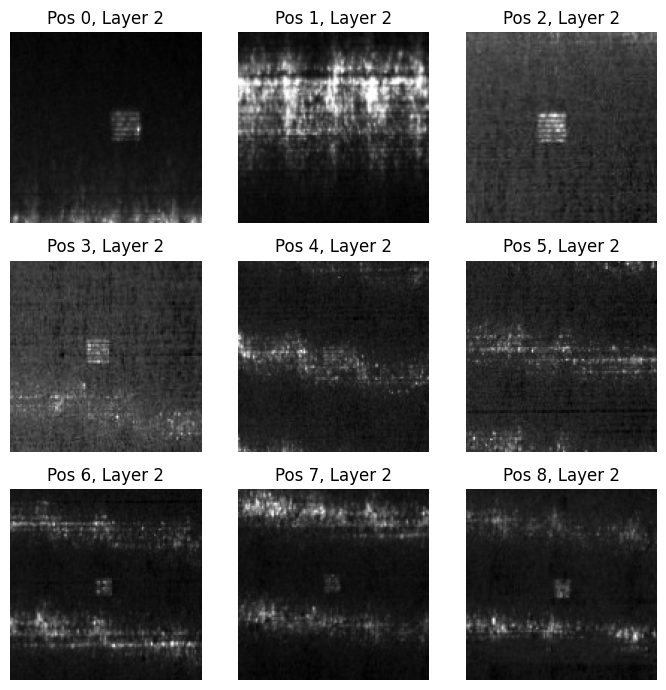

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
example_rows = labels.groupby("position", as_index=False).first().sort_values("position")
for ax, row in zip(axes.ravel(), example_rows.itertuples()):
    ax.imshow(patches[int(row.sample_id)], cmap="gray")
    ax.set_title(f"Pos {row.position}, Layer {row.layer}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Layer-basierter Train/Val/Test-Split

Die Crops derselben Schicht sind stark korreliert. Deshalb wird nach `layer` gruppiert gesplittet, damit keine fast identischen Nachbarinformationen gleichzeitig in Training und Test landen.


In [7]:
def split_contains_both_classes(indices: np.ndarray, labels_array: np.ndarray) -> bool:
    return len(np.unique(labels_array[indices])) == 2


def make_layer_splits(label_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray, str]:
    indices = np.arange(len(label_df))
    labels_array = label_df["pseudo_label"].to_numpy(dtype=np.int64)
    groups = label_df["layer"].to_numpy(dtype=np.int64)
    val_relative = cfg.val_fraction / max(1.0 - cfg.test_fraction, 1e-6)

    for seed_offset in range(200):
        splitter = GroupShuffleSplit(n_splits=1, test_size=cfg.test_fraction, random_state=SEED + seed_offset)
        train_val_idx, test_idx = next(splitter.split(indices, labels_array, groups))
        if not split_contains_both_classes(test_idx, labels_array):
            continue

        inner_groups = groups[train_val_idx]
        inner_labels = labels_array[train_val_idx]
        inner_indices = np.arange(len(train_val_idx))
        for inner_offset in range(100):
            inner_splitter = GroupShuffleSplit(n_splits=1, test_size=val_relative, random_state=SEED + seed_offset + inner_offset)
            train_rel, val_rel = next(inner_splitter.split(inner_indices, inner_labels, inner_groups))
            train_idx = train_val_idx[train_rel]
            val_idx = train_val_idx[val_rel]
            if split_contains_both_classes(train_idx, labels_array) and split_contains_both_classes(val_idx, labels_array):
                return train_idx, val_idx, test_idx, "grouped_by_layer"

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=cfg.test_fraction,
        random_state=SEED,
        stratify=labels_array,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=val_relative,
        random_state=SEED,
        stratify=labels_array[train_val_idx],
    )
    return train_idx, val_idx, test_idx, "stratified_random_fallback"

train_idx, val_idx, test_idx, split_strategy = make_layer_splits(labels)
labels["split"] = "train"
labels.loc[val_idx, "split"] = "val"
labels.loc[test_idx, "split"] = "test"

print("Split-Strategie:", split_strategy)
for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    counts = pd.Series(y[idx]).value_counts().reindex([0, 1], fill_value=0)
    layers = labels.iloc[idx]["layer"].nunique()
    print(f"{name:>5}: n={len(idx):4d}, layer={layers:4d}, regulaer={counts[0]:4d}, anomal={counts[1]:4d}")


Split-Strategie: grouped_by_layer
train: n=6804, layer= 756, regulaer=6441, anomal= 363
  val: n=1458, layer= 162, regulaer=1390, anomal=  68
 test: n=1467, layer= 163, regulaer=1385, anomal=  82


## 4. ResNet-18-Modell

Bevorzugt wird `torchvision.models.resnet18` mit ImageNet-Gewichten verwendet. Falls `torchvision` in der Umgebung fehlt, bleibt das Notebook lauffähig und verwendet eine lokal definierte ResNet-18-Architektur ohne Vortraining. Für die finale Abgabe ist der `torchvision`-Pfad vorzuziehen, weil er exakt die geforderte vortrainierte ResNet-Stufe abbildet.


In [8]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)
        return out


class LocalResNet18(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels: int, blocks: int, stride: int):
        layers = [BasicBlock(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward_features(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return torch.flatten(x, 1)

    def forward(self, x):
        return self.fc(self.forward_features(x))


def build_resnet18(num_classes: int = 2):
    if cfg.use_pretrained_resnet:
        try:
            from torchvision.models import ResNet18_Weights, resnet18

            weights = ResNet18_Weights.DEFAULT
            model = resnet18(weights=weights)
            if cfg.freeze_pretrained_backbone:
                for param in model.parameters():
                    param.requires_grad = False
            model.fc = nn.Linear(model.fc.in_features, num_classes)
            source = "torchvision.resnet18 ImageNet pretrained"
            mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
            std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
            return model, source, mean, std
        except Exception as exc:
            print("Kein torchvision-ResNet verfügbar, Fallback wird verwendet:", repr(exc))

    model = LocalResNet18(num_classes=num_classes)
    source = "local ResNet-18 fallback without ImageNet pretraining"
    mean = np.array([0.5, 0.5, 0.5], dtype=np.float32)
    std = np.array([0.5, 0.5, 0.5], dtype=np.float32)
    return model, source, mean, std

model, model_source, input_mean, input_std = build_resnet18(num_classes=2)
model = model.to(DEVICE)
print("Modell:", model_source)
print("Trainierbare Parameter:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/cervisiomatisch/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 44.4MB/s]

Modell: torchvision.resnet18 ImageNet pretrained
Trainierbare Parameter: 1026


In [9]:
class PatchClassificationDataset(Dataset):
    def __init__(self, patch_array: np.ndarray, labels_array: np.ndarray, indices: np.ndarray, mean: np.ndarray, std: np.ndarray):
        self.patch_array = patch_array
        self.labels_array = labels_array
        self.indices = np.asarray(indices, dtype=np.int64)
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, item: int):
        idx = int(self.indices[item])
        x = torch.from_numpy(self.patch_array[idx]).float().div(255.0).unsqueeze(0).repeat(3, 1, 1)
        x = (x - self.mean) / self.std
        target = torch.tensor(int(self.labels_array[idx]), dtype=torch.long)
        return x, target, idx

pin_memory = DEVICE.type == "cuda"
train_ds = PatchClassificationDataset(patches, y, train_idx, input_mean, input_std)
val_ds = PatchClassificationDataset(patches, y, val_idx, input_mean, input_std)
test_ds = PatchClassificationDataset(patches, y, test_idx, input_mean, input_std)
full_ds = PatchClassificationDataset(patches, y, np.arange(len(labels)), input_mean, input_std)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin_memory)
full_loader = DataLoader(full_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin_memory)


## 5. ResNet trainieren

Wegen der unausgeglichenen Pseudo-Labels wird die Cross-Entropy mit Klassengewichten trainiert. Bei einem vortrainierten `torchvision`-Modell wird standardmäßig nur der Klassifikationskopf trainiert; für Fine-Tuning kann `FREEZE_PRETRAINED_BACKBONE=0` gesetzt werden.


In [10]:
class_counts = np.bincount(y[train_idx], minlength=2).astype(np.float32)
class_weights = class_counts.sum() / (2.0 * np.maximum(class_counts, 1.0))
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=cfg.learning_rate, weight_decay=cfg.weight_decay)

print("Klassengewichte:", {int(i): float(w) for i, w in enumerate(class_weights)})


Klassengewichte: {0: 0.528178870677948, 1: 9.37190055847168}


In [11]:
def compute_binary_metrics(y_true: np.ndarray, prob_anomaly: np.ndarray, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true).astype(int)
    prob_anomaly = np.asarray(prob_anomaly).astype(float)
    pred = (prob_anomaly >= threshold).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "average_precision": float(average_precision_score(y_true, prob_anomaly)) if len(np.unique(y_true)) == 2 else float("nan"),
        "roc_auc": float(roc_auc_score(y_true, prob_anomaly)) if len(np.unique(y_true)) == 2 else float("nan"),
    }
    return metrics


def train_one_epoch(loader: DataLoader) -> float:
    model.train()
    total_loss = 0.0
    total_items = 0
    for x, target, _ in loader:
        x = x.to(DEVICE)
        target = target.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * len(target)
        total_items += len(target)
    return total_loss / max(total_items, 1)


@torch.no_grad()
def predict_loader(loader: DataLoader) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    model.eval()
    all_indices = []
    all_targets = []
    all_probs = []
    total_loss = 0.0
    total_items = 0
    for x, target, indices in loader:
        x = x.to(DEVICE)
        target = target.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, target)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_indices.extend(indices.cpu().numpy().tolist())
        all_targets.extend(target.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
        total_loss += float(loss.item()) * len(target)
        total_items += len(target)
    return (
        np.array(all_indices, dtype=np.int64),
        np.array(all_targets, dtype=np.int64),
        np.array(all_probs, dtype=np.float32),
        total_loss / max(total_items, 1),
    )


Epoch 001 | train_loss=0.2819 | val_loss=0.1617 | val_f1=0.694 | val_auc=0.994
Epoch 002 | train_loss=0.1286 | val_loss=0.0879 | val_f1=0.784 | val_auc=0.994
Epoch 003 | train_loss=0.1019 | val_loss=0.0816 | val_f1=0.766 | val_auc=0.996
Epoch 004 | train_loss=0.0839 | val_loss=0.0689 | val_f1=0.782 | val_auc=0.996
Epoch 005 | train_loss=0.0784 | val_loss=0.0625 | val_f1=0.812 | val_auc=0.996


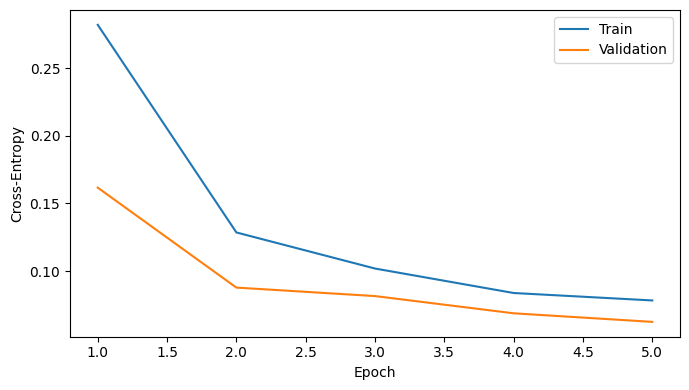

In [12]:
history = []
best_state = None
best_metric = -np.inf

for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(train_loader)
    _, val_targets, val_probs, val_loss = predict_loader(val_loader)
    val_metrics = compute_binary_metrics(val_targets, val_probs)
    selection_metric = val_metrics["roc_auc"]
    if np.isnan(selection_metric):
        selection_metric = val_metrics["f1"]

    if selection_metric > best_metric:
        best_metric = selection_metric
        best_state = deepcopy(model.state_dict())

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"val_{key}": value for key, value in val_metrics.items()},
    }
    history.append(row)
    print(
        f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_f1={val_metrics['f1']:.3f} | val_auc={val_metrics['roc_auc']:.3f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.to_csv(cfg.output_dir / "resnet_history.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "resnet_training_loss.png", dpi=160)
plt.show()


## 6. Klassifikationsmetriken und Vorhersagen speichern


In [13]:
all_indices, all_targets, all_probs, _ = predict_loader(full_loader)
prob_buffer = np.full(len(labels), np.nan, dtype=np.float32)
prob_buffer[all_indices] = all_probs

predictions = labels.copy()
predictions["resnet_prob_anomaly"] = prob_buffer
predictions["resnet_pred"] = (predictions["resnet_prob_anomaly"] >= 0.5).astype(int)
predictions.to_csv(cfg.output_dir / "resnet_predictions.csv", index=False)

metrics_by_split = {}
for split_name in ["train", "val", "test"]:
    split_df = predictions[predictions["split"] == split_name]
    metrics_by_split[split_name] = compute_binary_metrics(
        split_df["pseudo_label"].to_numpy(),
        split_df["resnet_prob_anomaly"].to_numpy(),
    )

metrics_payload = {
    "model_source": model_source,
    "split_strategy": split_strategy,
    "config": {key: str(value) for key, value in asdict(cfg).items()},
    "metrics": metrics_by_split,
}
with open(cfg.output_dir / "resnet_metrics.json", "w") as f:
    json.dump(metrics_payload, f, indent=2)

report = classification_report(
    predictions.loc[predictions["split"] == "test", "pseudo_label"],
    predictions.loc[predictions["split"] == "test", "resnet_pred"],
    target_names=["regulaer", "anomal"],
    zero_division=0,
)
(cfg.output_dir / "resnet_classification_report.txt").write_text(report)

print(json.dumps(metrics_payload["metrics"], indent=2))
print(report)

torch.save(
    {
        "model_state": model.state_dict(),
        "model_source": model_source,
        "input_mean": input_mean.tolist(),
        "input_std": input_std.tolist(),
        "config": {key: str(value) for key, value in asdict(cfg).items()},
    },
    cfg.output_dir / "resnet_classifier.pt",
)


{
  "train": {
    "accuracy": 0.9814814814814815,
    "precision": 0.7463617463617463,
    "recall": 0.9889807162534435,
    "f1": 0.8507109004739336,
    "average_precision": 0.9759404294963083,
    "roc_auc": 0.9984932100357431
  },
  "val": {
    "accuracy": 0.9787379972565158,
    "precision": 0.6907216494845361,
    "recall": 0.9852941176470589,
    "f1": 0.8121212121212121,
    "average_precision": 0.9172118111657818,
    "roc_auc": 0.9962653406686416
  },
  "test": {
    "accuracy": 0.983640081799591,
    "precision": 0.7735849056603774,
    "recall": 1.0,
    "f1": 0.8723404255319149,
    "average_precision": 0.978721769024832,
    "roc_auc": 0.9988993572246191
  }
}
              precision    recall  f1-score   support

    regulaer       1.00      0.98      0.99      1385
      anomal       0.77      1.00      0.87        82

    accuracy                           0.98      1467
   macro avg       0.89      0.99      0.93      1467
weighted avg       0.99      0.98      0.98

## 7. Confusion Matrix, ROC und Precision-Recall


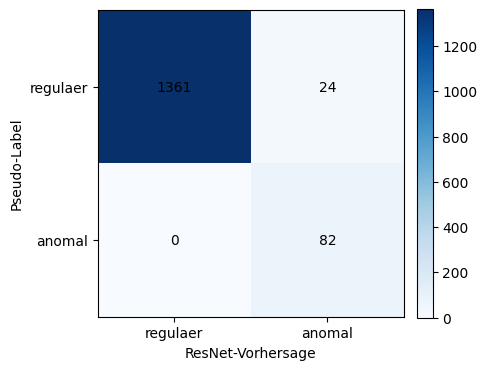

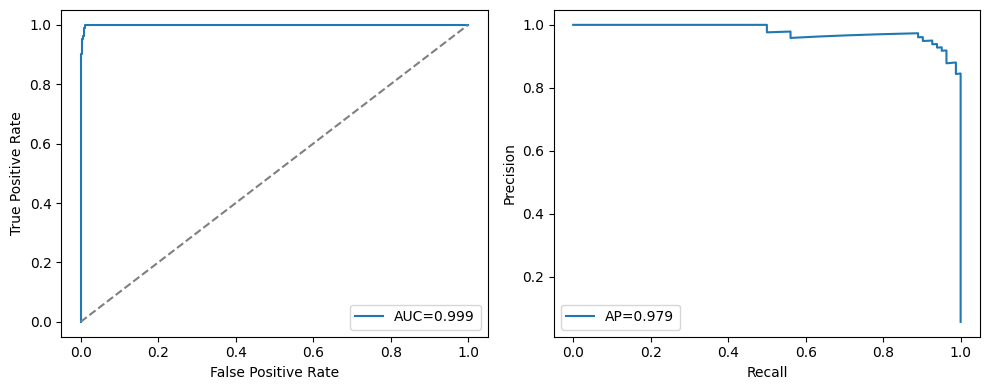

In [14]:
test_df = predictions[predictions["split"] == "test"].copy()
cm = confusion_matrix(test_df["pseudo_label"], test_df["resnet_pred"], labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["regulaer", "anomal"])
ax.set_yticks([0, 1], labels=["regulaer", "anomal"])
ax.set_xlabel("ResNet-Vorhersage")
ax.set_ylabel("Pseudo-Label")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, str(value), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "resnet_confusion_matrix.png", dpi=160)
plt.show()

if test_df["pseudo_label"].nunique() == 2:
    fpr, tpr, _ = roc_curve(test_df["pseudo_label"], test_df["resnet_prob_anomaly"])
    precision, recall, _ = precision_recall_curve(test_df["pseudo_label"], test_df["resnet_prob_anomaly"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(test_df['pseudo_label'], test_df['resnet_prob_anomaly']):.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="0.5")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()

    axes[1].plot(recall, precision, label=f"AP={average_precision_score(test_df['pseudo_label'], test_df['resnet_prob_anomaly']):.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "resnet_roc_pr_curves.png", dpi=160)
    plt.show()
else:
    print("ROC/PR-Kurven werden übersprungen, weil im Testsplit nur eine Klasse vorkommt.")


## 8. Schicht- und Bauteil-Auswertung

Diese Plots verbinden die Autoencoder-Scores mit der ResNet-Wahrscheinlichkeit. Für die bekannte Verdachtsschicht 715 wird eine Referenzlinie eingezeichnet.


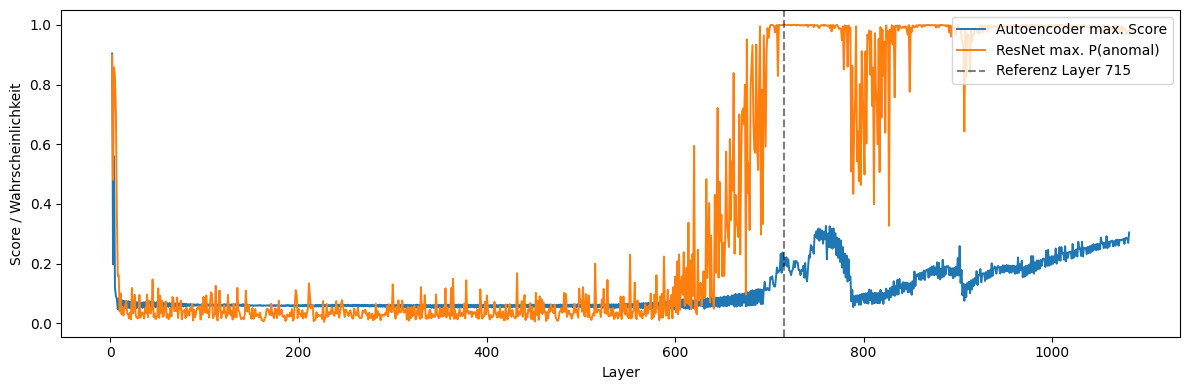

,position,samples,pseudo_anomaly_rate,ae_score_mean,resnet_prob_mean,resnet_prob_max
0,0,1081,0.084181,0.054192,0.132681,0.999954
1,1,1081,0.079556,0.045257,0.145940,0.999882
2,2,1081,0.186864,0.071025,0.228674,0.999872
3,3,1081,0.059204,0.043824,0.090989,1.000000
4,4,1081,0.008326,0.031932,0.041961,0.954667
5,5,1081,0.054579,0.041702,0.098181,0.990266
6,6,1081,0.000925,0.033024,0.023711,0.857460
7,7,1081,0.000925,0.026933,0.015680,0.630043
8,8,1081,0.000000,0.027936,0.016079,0.405358


In [15]:
layer_summary = predictions.groupby("layer", as_index=False).agg(
    ae_score_max=("anomaly_score", "max"),
    ae_score_mean=("anomaly_score", "mean"),
    resnet_prob_max=("resnet_prob_anomaly", "max"),
    resnet_prob_mean=("resnet_prob_anomaly", "mean"),
    pseudo_any=("pseudo_label", "max"),
)
layer_summary.to_csv(cfg.output_dir / "layer_anomaly_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(layer_summary["layer"], layer_summary["ae_score_max"], label="Autoencoder max. Score", linewidth=1.4)
ax.plot(layer_summary["layer"], layer_summary["resnet_prob_max"], label="ResNet max. P(anomal)", linewidth=1.4)
for layer in cfg.known_anomaly_layers:
    ax.axvline(layer, linestyle="--", color="black", alpha=0.5, label=f"Referenz Layer {layer}")
ax.set_xlabel("Layer")
ax.set_ylabel("Score / Wahrscheinlichkeit")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "layer_anomaly_curves.png", dpi=160)
plt.show()

position_summary = predictions.groupby("position", as_index=False).agg(
    samples=("pseudo_label", "size"),
    pseudo_anomaly_rate=("pseudo_label", "mean"),
    ae_score_mean=("anomaly_score", "mean"),
    resnet_prob_mean=("resnet_prob_anomaly", "mean"),
    resnet_prob_max=("resnet_prob_anomaly", "max"),
)
display(position_summary)
position_summary.to_csv(cfg.output_dir / "component_position_summary.csv", index=False)


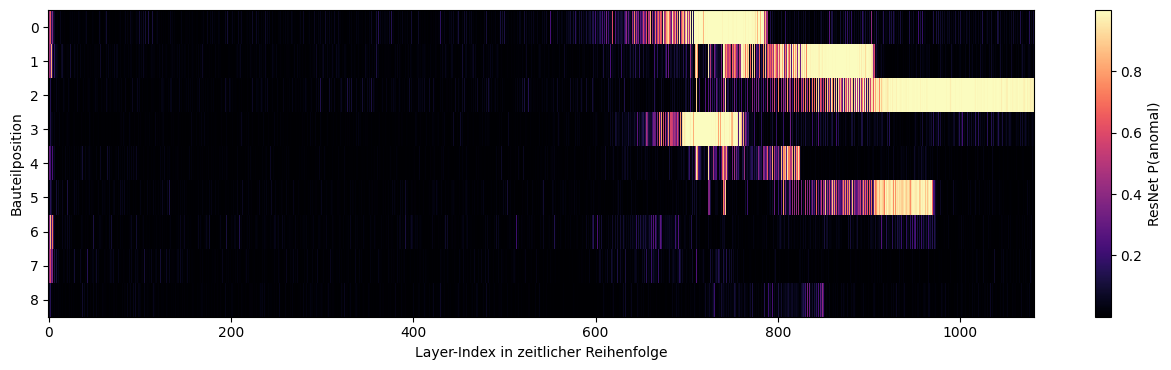

In [16]:
score_matrix = predictions.pivot_table(index="position", columns="layer", values="resnet_prob_anomaly", aggfunc="max")
fig, ax = plt.subplots(figsize=(13, 3.8))
im = ax.imshow(score_matrix.values, aspect="auto", cmap="magma", interpolation="nearest")
ax.set_yticks(np.arange(score_matrix.shape[0]), labels=score_matrix.index.tolist())
ax.set_xlabel("Layer-Index in zeitlicher Reihenfolge")
ax.set_ylabel("Bauteilposition")
fig.colorbar(im, ax=ax, label="ResNet P(anomal)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "component_layer_heatmap.png", dpi=160)
plt.show()


## 9. Korrelationen zwischen Autoencoder- und ResNet-Signalen


,layer,position,recon_error,latent_distance,anomaly_score,resnet_prob_anomaly,pseudo_label
layer,1.000000e+00,-1.876202e-15,0.086643,0.200788,0.203722,0.302191,0.243967
position,-1.876202e-15,1.000000e+00,-0.040257,-0.259574,-0.246325,-0.230616,-0.182752
recon_error,8.664317e-02,-4.025676e-02,1.000000,0.257630,0.472495,0.321414,0.333749
latent_distance,2.007884e-01,-2.595744e-01,0.257630,1.000000,0.973312,0.807617,0.788414
anomaly_score,2.037220e-01,-2.463250e-01,0.472495,0.973312,1.000000,0.812984,0.798397
resnet_prob_anomaly,3.021908e-01,-2.306162e-01,0.321414,0.807617,0.812984,1.000000,0.872326
pseudo_label,2.439665e-01,-1.827524e-01,0.333749,0.788414,0.798397,0.872326,1.000000


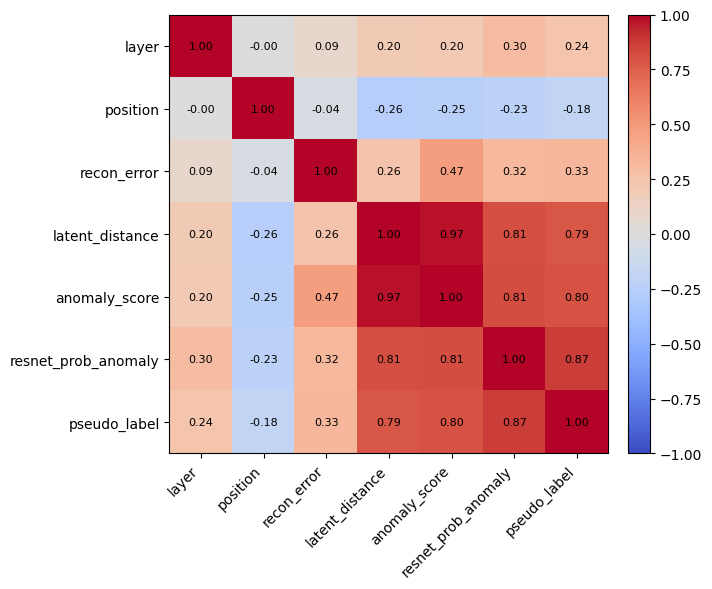

In [17]:
corr_columns = [
    "layer",
    "position",
    "recon_error",
    "latent_distance",
    "anomaly_score",
    "resnet_prob_anomaly",
    "pseudo_label",
]
corr = predictions[corr_columns].corr(numeric_only=True)
display(corr)
corr.to_csv(cfg.output_dir / "score_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(np.arange(len(corr.columns)), labels=corr.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr.index)), labels=corr.index)
for (i, j), value in np.ndenumerate(corr.values):
    ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "score_correlation_matrix.png", dpi=160)
plt.show()


## 10. Top-Anomalien visuell prüfen


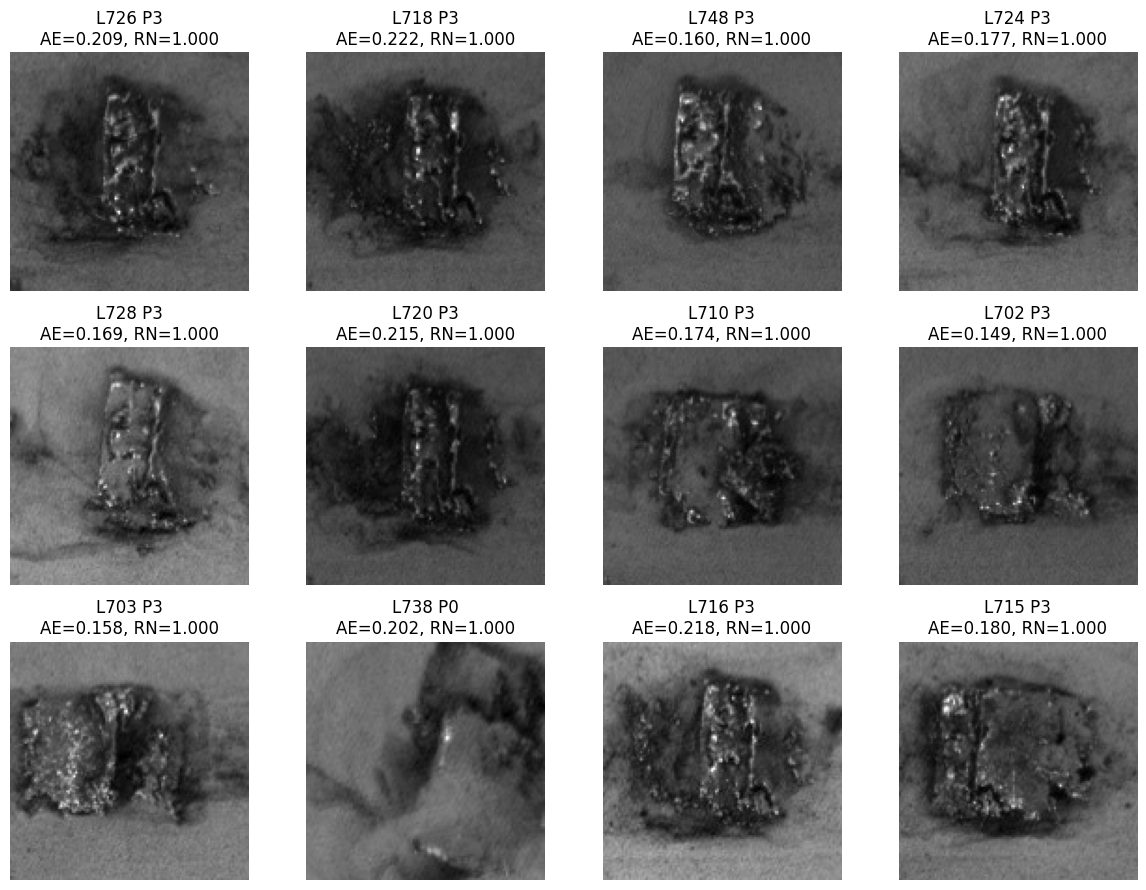

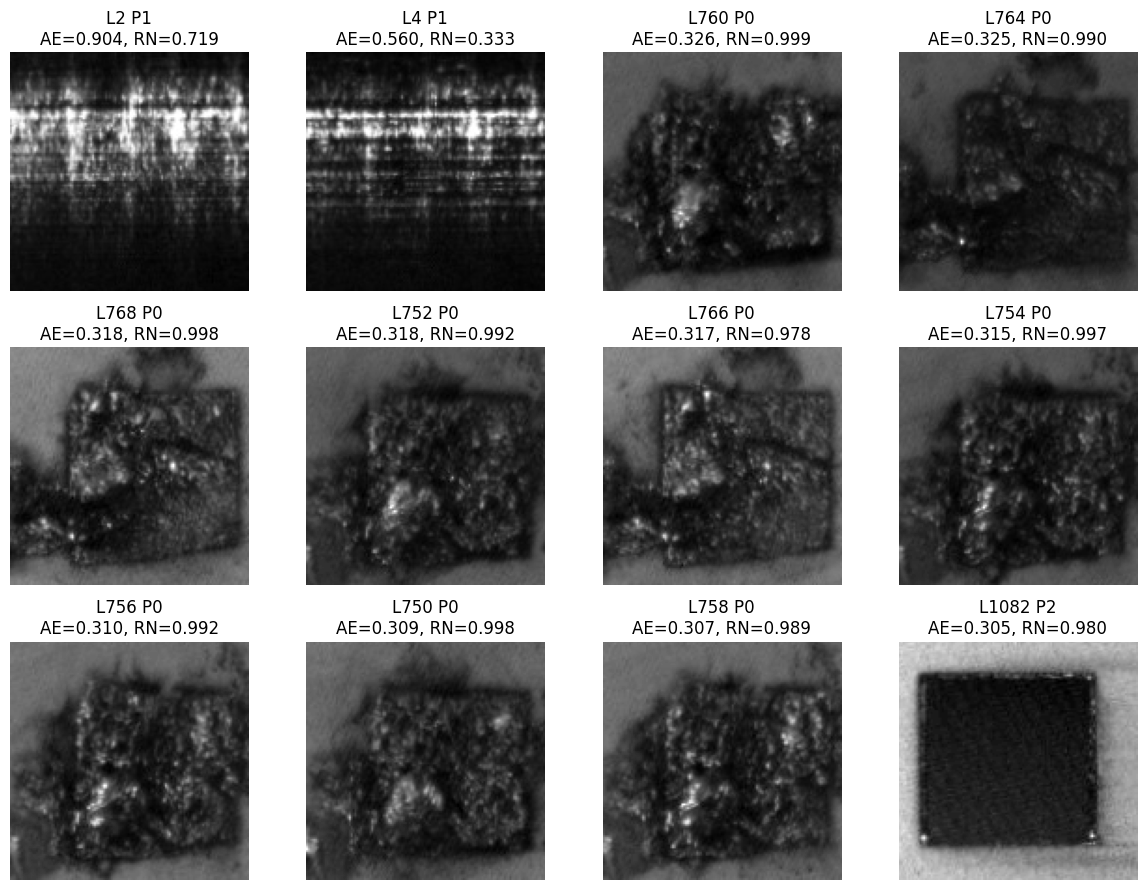

In [18]:
def show_top_predictions(pred_df: pd.DataFrame, patch_array: np.ndarray, score_column: str, n: int = 12):
    top = pred_df.sort_values(score_column, ascending=False).head(n)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.asarray(axes).ravel()
    for ax, row in zip(axes, top.itertuples()):
        ax.imshow(patch_array[int(row.sample_id)], cmap="gray")
        title = f"L{row.layer} P{row.position}\nAE={row.anomaly_score:.3f}, RN={row.resnet_prob_anomaly:.3f}"
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(top):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"top_{score_column}.png", dpi=160)
    plt.show()

show_top_predictions(predictions, patches, "resnet_prob_anomaly", n=12)
show_top_predictions(predictions, patches, "anomaly_score", n=12)


## 11. ResNet-Feature-Projektion

Als einfache Latent-Space-Visualisierung werden die Merkmale vor der finalen Klassifikationsschicht per PCA auf zwei Dimensionen projiziert. Das erfüllt dieselbe diagnostische Funktion wie t-SNE/UMAP, ist aber deterministisch und ohne zusätzliche Bibliotheken verfügbar.


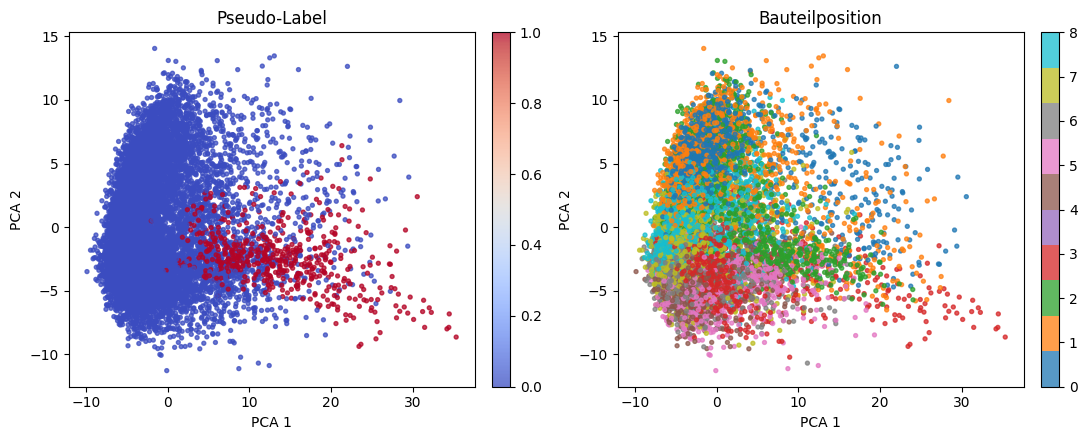

Erklärte Varianz der ersten zwei PCA-Komponenten: [0.08116391 0.04533404]


In [19]:
def make_feature_extractor(current_model: nn.Module):
    if hasattr(current_model, "forward_features"):
        return current_model.forward_features
    backbone = nn.Sequential(*list(current_model.children())[:-1]).to(DEVICE)

    def extract(x):
        return torch.flatten(backbone(x), 1)

    return extract


@torch.no_grad()
def extract_features(loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    feature_fn = make_feature_extractor(model)
    all_indices = []
    all_features = []
    for x, _, indices in loader:
        x = x.to(DEVICE)
        features = feature_fn(x)
        all_indices.extend(indices.cpu().numpy().tolist())
        all_features.append(features.cpu().numpy())
    return np.array(all_indices, dtype=np.int64), np.concatenate(all_features, axis=0)

feature_indices, features = extract_features(full_loader)
features_ordered = np.empty_like(features)
features_ordered[feature_indices] = features

pca = PCA(n_components=2, random_state=SEED)
projection = pca.fit_transform(features_ordered)
projection_df = predictions[["sample_id", "layer", "position", "pseudo_label", "anomaly_score", "resnet_prob_anomaly"]].copy()
projection_df["pca_1"] = projection[:, 0]
projection_df["pca_2"] = projection[:, 1]
projection_df.to_csv(cfg.output_dir / "resnet_feature_pca.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
scatter0 = axes[0].scatter(
    projection_df["pca_1"],
    projection_df["pca_2"],
    c=projection_df["pseudo_label"],
    cmap="coolwarm",
    s=8,
    alpha=0.75,
)
axes[0].set_title("Pseudo-Label")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
fig.colorbar(scatter0, ax=axes[0], fraction=0.046, pad=0.04)

scatter1 = axes[1].scatter(
    projection_df["pca_1"],
    projection_df["pca_2"],
    c=projection_df["position"],
    cmap="tab10",
    s=8,
    alpha=0.75,
)
axes[1].set_title("Bauteilposition")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
fig.colorbar(scatter1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "resnet_feature_pca.png", dpi=160)
plt.show()

print("Erklärte Varianz der ersten zwei PCA-Komponenten:", pca.explained_variance_ratio_)
